# Sensitivity Analysis - Random Forest + SHAP

### Final Version

For this version, we remove the columns that had unbalanced registered samples, and/or biases.

### Data Pre-Processing

We start by preparing our Dataframe. First, we will load the data and libraries required.

**NOTE:** We are required to use NumPy 2.2 or below (specified on requirements.txt), for using shap library, due to compatibility issues.

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import json
import re
import shap # For SHAP method execution
from sklearn.ensemble import RandomForestRegressor # For construction of surrogate model
from sklearn.model_selection import train_test_split # For training and testing of the model
from tqdm import tqdm

/opt/conda/lib/python3.11/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


An exploratory analysis, as well as a data cleaning process, was made before for constructing the working dataframe. For required reference, consult the latest version of 'eda' noteboook, as well as 'df_cleaning'.

We continue by loading our dataframe.

In [2]:
df = pd.read_csv("./data/cleaned_df.csv")

We define the input and output columns before training the surrogate models.

In [3]:
# Inputs Based on Dataframe
inputs_list = ['fdfm','lfm','wind_speed', 'gap_length', 'spacing_distance', 'igniter_velocity', 'wind_direction'] 

# Outputs Based on Dataframe
outputs_list = ['surface_consumed', 'midstory_consumed', 'canopy_consumed']


In [4]:
# Number of observations of df
print(len(df))

7886


We drop the columns with biased sample distribution, according to the EDA.

In [5]:
# We drop the columns with non-normal and/or biased distribution
df = df.drop(columns=['dash_length', 'side_to_start_ignition', 'blackline_width', 'wind_height', 'firing_technique'])

# Drop rows with missing values in all input columns (no outputs)
columns_to_exclude = ['midstory_consumed', 'canopy_consumed', 'surface_consumed', 'dash_length', 
                      'side_to_start_ignition', 'blackline_width', 'wind_height', 'firing_technique',
                      'fuel_id', 'unit_feature_id']

# Get all columns except outputs
columns_to_check = [col for col in df.columns if col not in columns_to_exclude]

# Drop rows that have missing values in inputs
df_cleaned = df.dropna(subset=columns_to_check)

# Number of observations of df
print(len(df_cleaned))

6555


We declare the number of seeds to be implemented, as well as the runs.

In [6]:
# Random seeds generations
NUM_RUNS = 10
np.random.seed(42)
seeds = np.random.randint(0, 10**6, size=NUM_RUNS)

Now, we create the nested dictionary, to be used.

In [7]:
shap_results = {output: {feature: [] for feature in inputs_list} for output in outputs_list}

We can now form a loop for training and executing each sensitivity analysis per output. We append them for future reference if required too.

In [8]:
for output in tqdm(outputs_list, desc="Outputs"):
    # Drop rows with missing output values
    df_clean = df_cleaned.dropna(subset=[output])

    for run in tqdm(range(NUM_RUNS), desc=f"Seeds for {output}", leave=False):
        seed = seeds[run]

        X = df_clean[inputs_list]
        y = df_clean[output]

        X_train, X_test, y_train, y_test = train_test_split(
            X, y, test_size=0.2, random_state=seed
        )

        model = RandomForestRegressor(random_state=seed)
        model.fit(X_train, y_train)

        explainer = shap.TreeExplainer(model)
        shap_values = explainer.shap_values(X_test)

        # For each feature, append rounded SHAP values for this run
        for i, feature in enumerate(inputs_list):
            rounded_vals = np.round(shap_values[:, i], 2)
            shap_results[output][feature].extend(rounded_vals)

Outputs: 100%|██████████| 3/3 [29:18<00:00, 586.23s/it]                   


We may now visualize each SHAP analysis per output, for future interpretation.

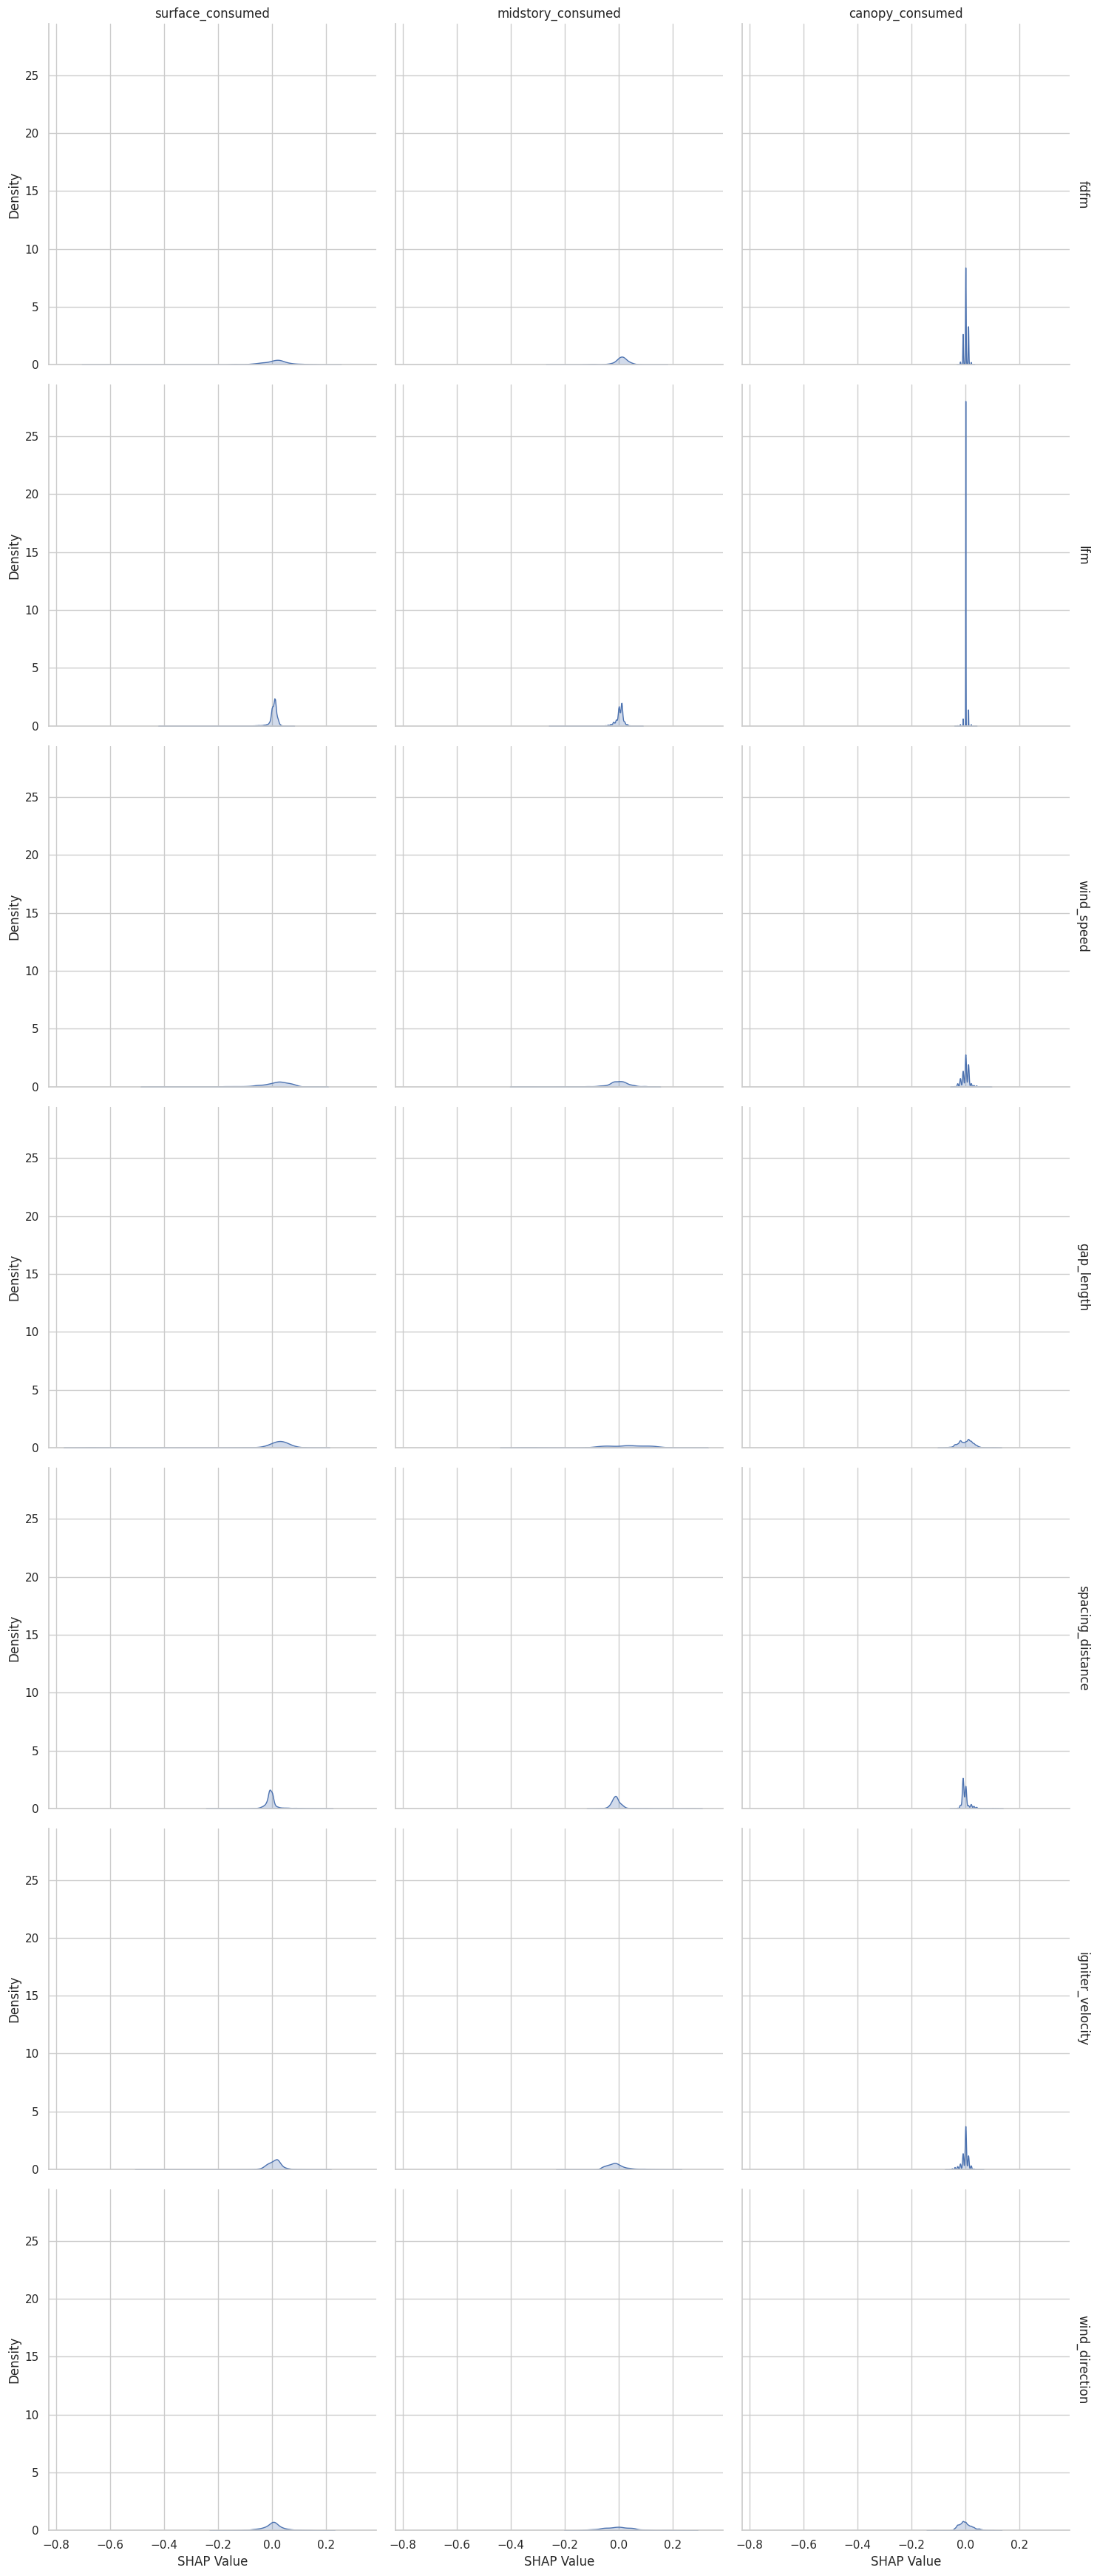

In [13]:
# Build a DataFrame for plotting
plot_dfs = []
for output, feat_dict in shap_results.items():
    for feature, values in feat_dict.items():
        df_temp = pd.DataFrame({
            "SHAP Value": values,
            "Input Feature": feature,
            "Output": output
        })
        plot_dfs.append(df_temp)

plot_df = pd.concat(plot_dfs, ignore_index=True)

#  KDE plots for each feature per × output
sns.set(style="whitegrid")
g = sns.displot(
    data=plot_df,
    x="SHAP Value",
    col="Output",
    row="Input Feature",
    kind="kde",
    fill=True,
    facet_kws={'margin_titles': True}
)
g.set_titles(col_template="{col_name}", row_template="{row_name}")
plt.tight_layout()
plt.show()